In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt

path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import ghost_correct as gc


# import nustar_dem_prep as nu
# import all_nu_analysis as ana
# import nustar_utilities as nuutil
# import region_fitting as rf

# import pickle
# import numpy as np
# from matplotlib import pyplot as plt
# from astropy import units as u

# import sunpy.map
# import glob
# from astropy.io import fits
# import nustar_pysolar as nustar

# from astropy.coordinates import SkyCoord
# from astropy import coordinates as coord
# from regions import CircleSkyRegion

In [2]:
all_targets_file_wnew='/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle'
with open(all_targets_file_wnew, 'rb') as f:
    all_targets = pickle.load(f)

dict_keys(['NOAA_ARID', 'HARP', 'datapaths', 'obsids', 'ghost_ray_flag', 'obvious ghost rays', 'working_dir', 'loc', 'hale_class', 'method', 'notes', 'goes_satellite', 'orbit durations', 'total duration', 'total livetime', 'Region Coordinates', 'region_stats', 'directories', 'sub_keys', 'res_file_dict(s)', 'HARP params', 'Region Ages', 'per_region_all_time_intervals', 'per_region_quiet_time_intervals', 'nushift', 'regdicts', 'Ghost_Ray_Rate_A', 'Ghost_Ray_Rate_B'])
ONLY DID IT FOR FIRST REGION
/Users/jmdunca2/do-dem/DEM_folders//initial_dem_3jun22_2/gauss_cen_20624004001_A_user_input_0.reg
ONLY DID IT FOR FIRST REGION
/Users/jmdunca2/do-dem/DEM_folders//initial_dem_3jun22_2/gauss_cen_20624004001_B_user_input_0.reg
ONLY DID IT FOR FIRST REGION
/Users/jmdunca2/do-dem/DEM_folders//initial_dem_3jun22_2/gauss_cen_20624006001_A_user_input_0.reg
ONLY DID IT FOR FIRST REGION
/Users/jmdunca2/do-dem/DEM_folders//initial_dem_3jun22_2/gauss_cen_20624006001_B_user_input_0.reg


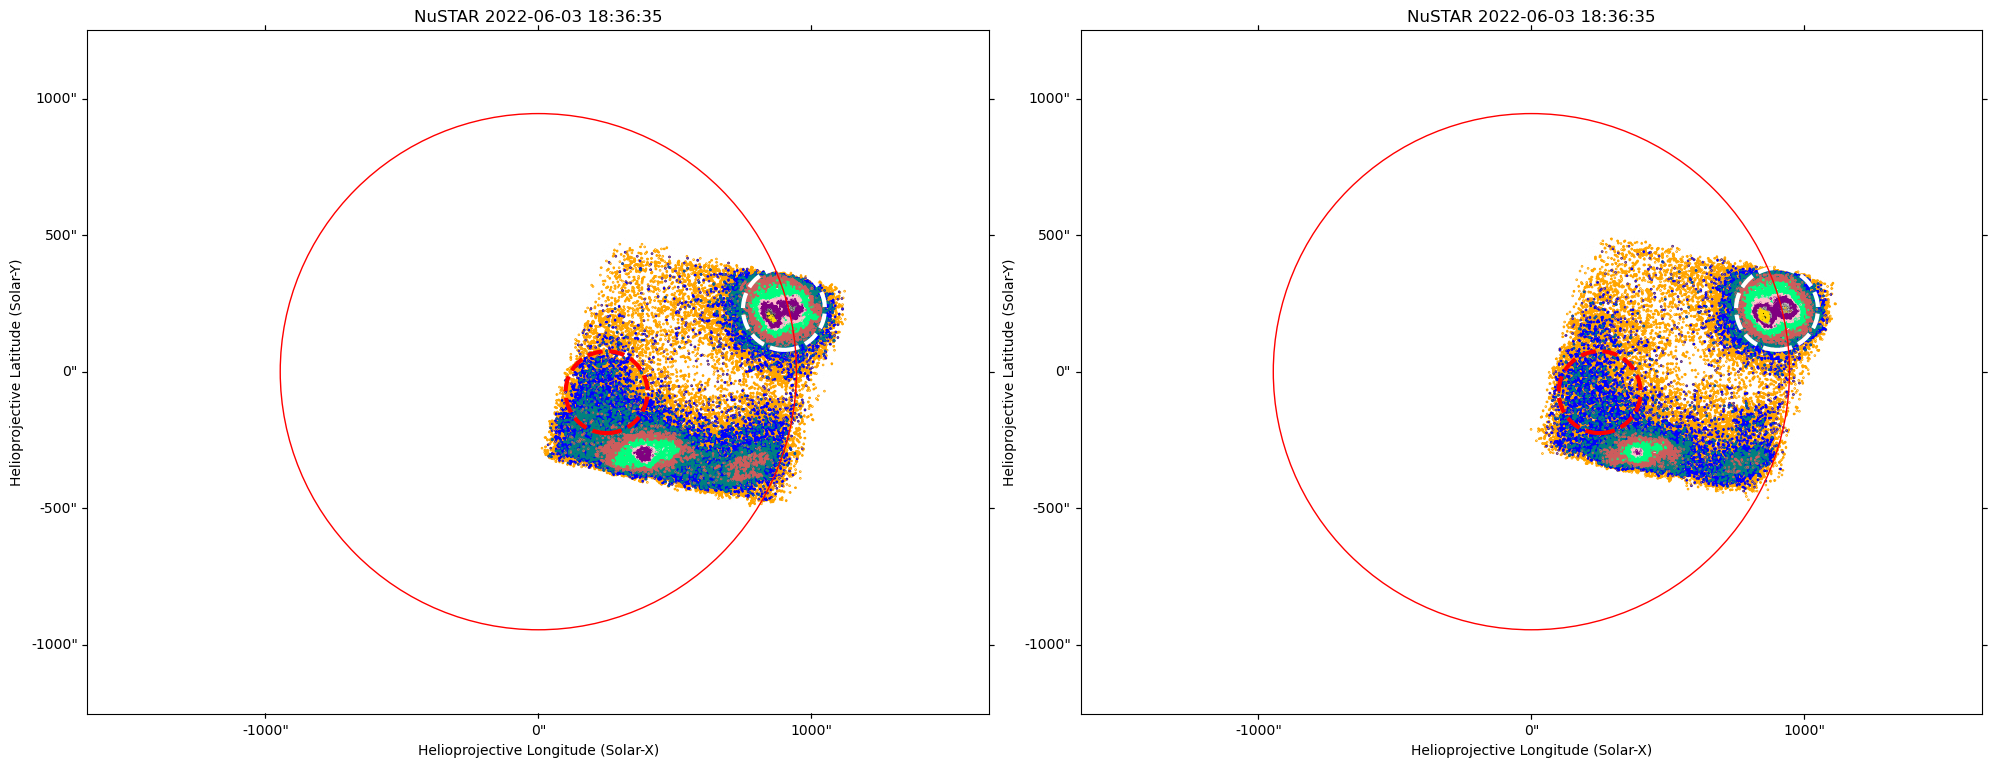

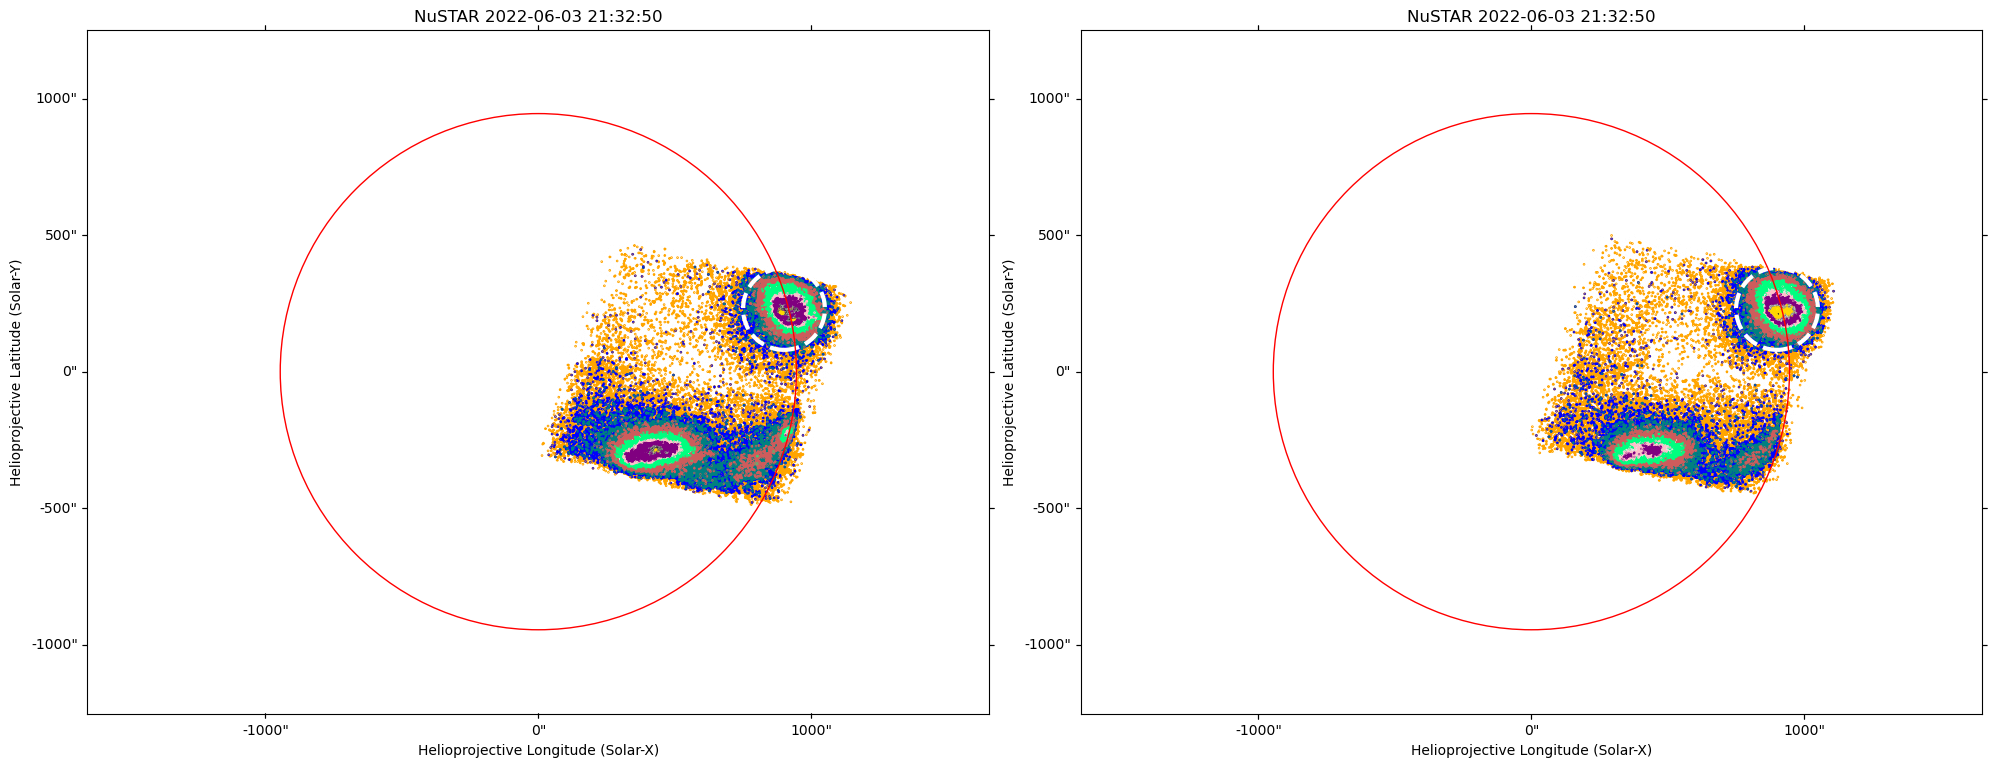

In [4]:



#key='11-dec-22_2'
#gregion = {'centerx': 750.0, 'centery': 65.0, 'radius': 150.0}
#gorbit=0

#If single gaussian fit region:
#Currently the way I modified this, you need to have both the plot options true to write the single gauss regions to a file.
#ana.single_gauss_prep(key, all_targets_file_wnew, plot=True, write_gauss_regions=True,
#                     plotgaussregions=True)


key='03-jun-22_2'
gregion = {'centerx': 250.0, 'centery': -75.0, 'radius': 150.0}
gorbit=0

# key='30-jul-21_1'
# gregion = {'centerx': 800.0, 'centery': -100.0, 'radius': 150.0}
# gorbit=1

# key='30-jul-21_2'
# gregion = {'centerx': 650.0, 'centery': 100.0, 'radius': 150.0}
# gorbit=0

# key='01-nov-14_1'
# gregion = {'centerx': 640.0, 'centery': -490.0, 'radius': 150.0}
# gorbit=0

# key='29-may-18_2'
# gregion = {'centerx': 380.0, 'centery': 400.0, 'radius': 150.0}
# #gregion = {'centerx': 420.0, 'centery': 200.0, 'radius': 150.0}
# gorbit=0

# key='30-jul-21_2'
# #gregion = {'centerx': 650.0, 'centery': 100.0, 'radius': 150.0}
# gregion = {'centerx': 1000.0, 'centery': 100.0, 'radius': 150.0}
# gorbit=0
#Get the region correct before switching to True or you'll waste a lot of time.
go_ahead=False
write_new_file=True

print(all_targets[key].keys())

#ana.single_gauss_prep(key, all_targets_file_wnew, plot=True, write_gauss_regions=True,
#                      plotgaussregions=True)


#make sure you do this with the same energy ranges you want for the DEM.
eng_tr = [[2.5, 3.5], [3.5, 6.], [6., 10.]]
gc.make_ghost_region(key, all_targets_file_wnew, gregion=gregion, gorbit=gorbit, go_ahead=go_ahead, write_new_file=write_new_file)



In [15]:
#For when you need to use a ghost ray rate from a different key
with open(all_targets_file_wnew, 'rb') as f:
    all_targets = pickle.load(f)
    
#recievers = ['19-nov-21', '20-nov-21']
#donor='17-nov-21_2'

recievers = ['22-nov-21_1']
donor='21-nov-21'

# recievers = ['24-feb-22']
# donor='25-feb-22'

for kk in recievers:
    all_targets[kk]['Ghost_Ray_Rate_A'] = all_targets[donor]['Ghost_Ray_Rate_A']
    all_targets[kk]['Ghost_Ray_Rate_B'] = all_targets[donor]['Ghost_Ray_Rate_B']

with open(all_targets_file_wnew, 'wb') as f:
     # Pickle the 'data' dictionary using the highest protocol available.
     pickle.dump(all_targets, f, pickle.HIGHEST_PROTOCOL)